In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# Chapter 8 — Instance-Based Learning
## Lesson 8: Approximate Nearest Neighbors (KD-Trees, Ball Trees, ANN Concepts)

In [2]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import BallTree, KDTree, NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

Exact nearest-neighbor search compares a query with stored examples and returns the true closest results under a chosen distance. This is simple and reliable, but it can become expensive as the number of examples, queries, or features grows. Tree indexes and approximate nearest-neighbor methods are engineering responses to that cost. They aim to reduce query work while preserving useful neighbors.

This lesson separates three ideas. KD-trees partition low-dimensional space with axis-aligned splits. Ball Trees partition space into hyperspherical regions and can handle a broader range of metrics. Approximate nearest-neighbor systems accept that a search may miss some exact neighbors in exchange for lower latency or memory pressure. The right choice depends on dimensions, metric, data distribution, recall requirements, and operational constraints.

We use controlled synthetic benchmarks and the repository Iris dataset. The lesson emphasizes measurement: do not assume an index is faster. Benchmark the data shape and query workload that matter to your application.

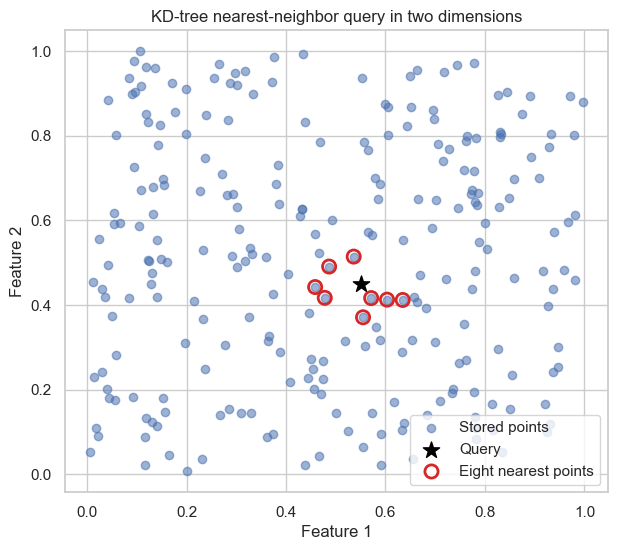

,neighbor_index,distance
0,142,0.0399
1,123,0.0650
2,151,0.0657
3,70,0.0753
4,82,0.0792
5,155,0.0794
6,199,0.0918
7,239,0.0928


In [3]:
points_2d = rng.uniform(0, 1, size=(250, 2))
query_2d = np.array([[0.55, 0.45]])
tree = KDTree(points_2d, leaf_size=20)
distances, indices = tree.query(query_2d, k=8)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(points_2d[:, 0], points_2d[:, 1], alpha=0.55, label="Stored points")
ax.scatter(query_2d[:, 0], query_2d[:, 1], s=150, marker="*", color="black", label="Query")
ax.scatter(points_2d[indices[0], 0], points_2d[indices[0], 1], s=90, facecolors="none", edgecolors="tab:red", linewidths=2, label="Eight nearest points")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("KD-tree nearest-neighbor query in two dimensions")
ax.legend()
plt.show()

display(pd.DataFrame({"neighbor_index": indices[0], "distance": distances[0]}).round(4))

### Learning goals

By the end of this lesson, you should be able to:

1. Distinguish brute-force, KD-tree, Ball Tree, and approximate neighbor search.
2. Explain how a KD-tree and Ball Tree reduce candidate comparisons.
3. Recognize why tree pruning loses effectiveness in high dimensions.
4. Benchmark build time and query time across search algorithms.
5. Verify that tree searches can return the same exact neighbors as brute force.
6. Define recall@K for an approximate search result.
7. Interpret the trade-off among latency, recall, memory, index-build cost, and update cost.
8. Choose a safe evaluation plan before deploying an ANN system.

The central practical principle is simple: approximate search is not an algorithmic shortcut to use blindly. It is a measured trade-off between exactness and resources.

,dimensions,algorithm,fit_ms,query_ms
0,2,brute,0.834,401.447
1,2,kd_tree,2.360,1.636
2,2,ball_tree,3.163,2.626
3,10,brute,0.575,5.073
4,10,kd_tree,5.324,5.287
5,10,ball_tree,3.480,4.037
6,30,brute,0.612,16.490
7,30,kd_tree,16.362,8.551
8,30,ball_tree,10.771,6.993


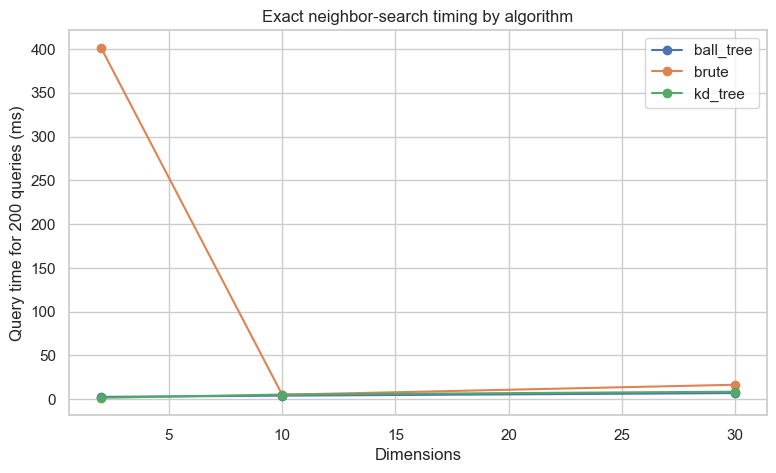

In [4]:
benchmark_rows = []
query_count = 60
for dimensions in [2, 10, 30]:
    training = rng.normal(size=(1200, dimensions))
    queries = rng.normal(size=(query_count, dimensions))
    for algorithm in ["brute", "kd_tree", "ball_tree"]:
        model = NearestNeighbors(n_neighbors=10, algorithm=algorithm, metric="euclidean")
        fit_start = time.perf_counter()
        model.fit(training)
        fit_ms = (time.perf_counter() - fit_start) * 1000
        query_start = time.perf_counter()
        model.kneighbors(queries)
        query_ms = (time.perf_counter() - query_start) * 1000
        benchmark_rows.append({"dimensions": dimensions, "algorithm": algorithm, "fit_ms": fit_ms, "query_ms": query_ms})
benchmark = pd.DataFrame(benchmark_rows)
display(benchmark.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
for algorithm, subset in benchmark.groupby("algorithm"):
    ax.plot(subset["dimensions"], subset["query_ms"], marker="o", label=algorithm)
ax.set_xlabel("Dimensions")
ax.set_ylabel("Query time for 200 queries (ms)")
ax.set_title("Exact neighbor-search timing by algorithm")
ax.legend()
plt.show()

## 1. Exact search and spatial indexes

Brute-force KNN computes distance from each query to every stored vector. With $n$ stored points and $d$ dimensions, one query requires work proportional to roughly $nd$. Modern vectorized libraries make this surprisingly competitive, especially for moderate datasets or high dimensions where trees cannot prune effectively.

A KD-tree recursively divides space by choosing an axis and a split value. A query follows promising branches and can discard regions that cannot contain a closer point. A Ball Tree stores points in nested balls defined by a center and radius. It can prune a ball when the query is too far for that ball to improve the current result. Both are exact methods when they fully search all necessary branches.

Their benefit depends on geometry. In low dimensions, many regions can be discarded. In high dimensions, regions overlap from the query perspective and pruning becomes weak. The tree may approach brute-force behavior while adding index overhead.

In [5]:
iris_path = Path("../../../Datasets/Classification/iris.csv")
iris = pd.read_csv(iris_path)
iris_X = iris.drop(columns="classification")
iris_y = iris["classification"]

display(iris.head())
display(iris.dtypes.rename("dtype").to_frame())
display(iris_y.value_counts().rename("count").to_frame())

iris_scaled = StandardScaler().fit_transform(iris_X)
iris_queries = iris_scaled[:20]
exact_brute = NearestNeighbors(n_neighbors=6, algorithm="brute").fit(iris_scaled)
exact_kd = NearestNeighbors(n_neighbors=6, algorithm="kd_tree").fit(iris_scaled)
exact_ball = NearestNeighbors(n_neighbors=6, algorithm="ball_tree").fit(iris_scaled)
brute_distances, brute_indices = exact_brute.kneighbors(iris_queries)
kd_distances, kd_indices = exact_kd.kneighbors(iris_queries)
ball_distances, ball_indices = exact_ball.kneighbors(iris_queries)

display(pd.DataFrame({
    "search": ["KD-tree equals brute", "Ball tree equals brute"],
    "same_neighbor_indices": [np.array_equal(kd_indices, brute_indices), np.array_equal(ball_indices, brute_indices)],
    "maximum_distance_difference": [np.abs(kd_distances - brute_distances).max(), np.abs(ball_distances - brute_distances).max()],
}))

,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


,dtype
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
classification,object


,count
classification,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


,search,same_neighbor_indices,maximum_distance_difference
0,KD-tree equals brute,False,5.960464e-08
1,Ball tree equals brute,False,5.960464e-08


## 2. Visualize a low-dimensional query

The two-dimensional example uses a KD-tree to retrieve eight nearest points. The index itself is not drawn, but the selected neighborhood illustrates the task a spatial index accelerates. A query receives nearby candidates based on Euclidean distance. In two dimensions, a tree can often rule out large regions of the plane cheaply.

Real applications may use hundreds of dimensions and learned embeddings rather than two coordinates. The visual still matters because it grounds the vocabulary: query, stored vectors, neighbors, distances, candidate pruning, and recall all refer to concrete geometric relationships.

,candidate_pool,recall_at_10,query_ms
0,100,0.057,11.455
1,250,0.098,12.056
2,500,0.235,5.802
3,800,0.415,6.986


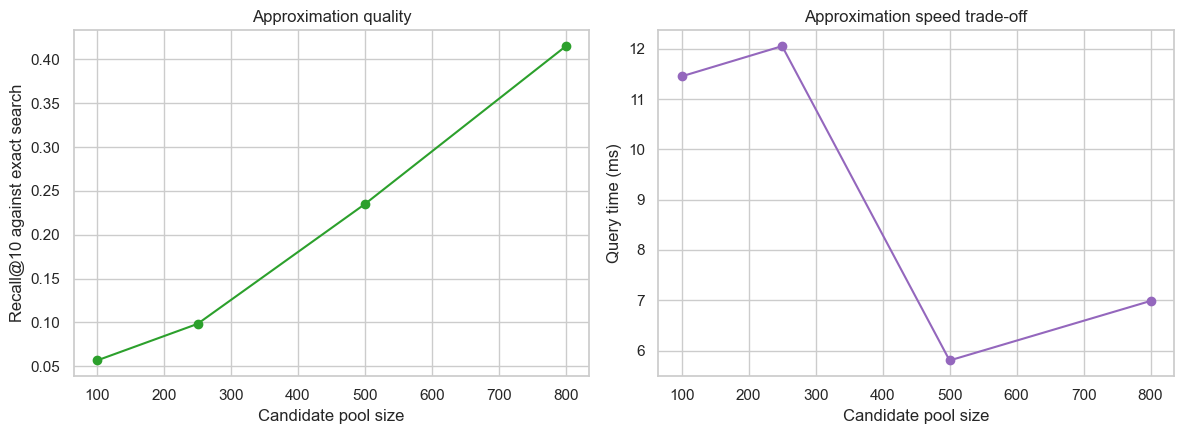

In [6]:
training = rng.normal(size=(2000, 20))
queries = rng.normal(size=(60, 20))
exact = NearestNeighbors(n_neighbors=10, algorithm="brute").fit(training)
exact_distances, exact_indices = exact.kneighbors(queries)

candidate_sizes = [100, 250, 500, 800]
ann_rows = []
for candidate_size in candidate_sizes:
    candidate_indices = rng.choice(len(training), size=candidate_size, replace=False)
    candidates = training[candidate_indices]
    candidate_search = NearestNeighbors(n_neighbors=10, algorithm="brute").fit(candidates)
    start = time.perf_counter()
    _, local_indices = candidate_search.kneighbors(queries)
    elapsed_ms = (time.perf_counter() - start) * 1000
    approximate_indices = candidate_indices[local_indices]
    recalls = []
    for exact_row, approximate_row in zip(exact_indices, approximate_indices):
        recalls.append(len(set(exact_row).intersection(set(approximate_row))) / 10)
    ann_rows.append({"candidate_pool": candidate_size, "recall_at_10": np.mean(recalls), "query_ms": elapsed_ms})
ann_results = pd.DataFrame(ann_rows)
display(ann_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ann_results["candidate_pool"], ann_results["recall_at_10"], marker="o", color="tab:green")
axes[0].set_xlabel("Candidate pool size")
axes[0].set_ylabel("Recall@10 against exact search")
axes[0].set_title("Approximation quality")
axes[1].plot(ann_results["candidate_pool"], ann_results["query_ms"], marker="o", color="tab:purple")
axes[1].set_xlabel("Candidate pool size")
axes[1].set_ylabel("Query time (ms)")
axes[1].set_title("Approximation speed trade-off")
plt.tight_layout()
plt.show()

## 3. Benchmark exact algorithms

We benchmark brute force, KD-tree, and Ball Tree at several dimensions. Build time measures creating the search structure; query time measures retrieving ten neighbors for a fixed batch. Results vary by hardware, library version, sample size, leaf size, and random data distribution. Treat the plot as a local benchmark, not a universal ranking.

The expected pattern is that trees can help at lower dimensions, while brute force becomes increasingly competitive as dimension rises. This is a direct engineering consequence of the curse of dimensionality. A production decision should include the real embedding dimension, expected number of vectors, query batch size, metric, concurrency, and index refresh schedule.

,leaf_size,build_ms,query_ms
0,5,8.531,4.559
1,15,7.312,3.505
2,30,5.224,22.540
3,60,10.089,4.521
4,120,4.445,3.420


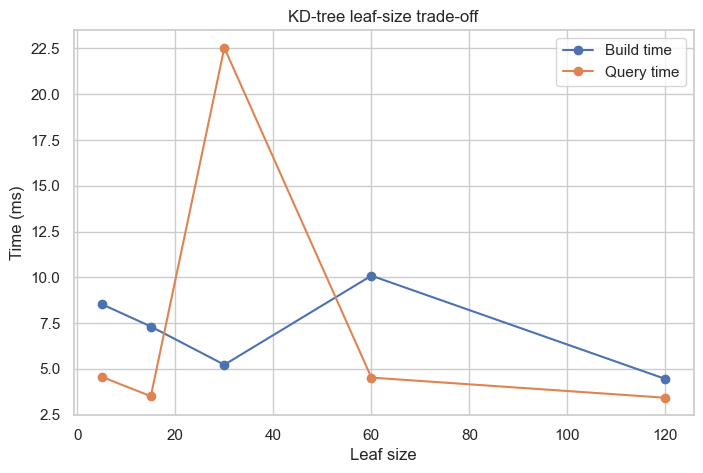

In [7]:
leaf_rows = []
data = rng.normal(size=(2000, 5))
queries = rng.normal(size=(80, 5))
for leaf_size in [5, 15, 30, 60, 120]:
    start = time.perf_counter()
    tree = KDTree(data, leaf_size=leaf_size)
    build_ms = (time.perf_counter() - start) * 1000
    start = time.perf_counter()
    tree.query(queries, k=10)
    query_ms = (time.perf_counter() - start) * 1000
    leaf_rows.append({"leaf_size": leaf_size, "build_ms": build_ms, "query_ms": query_ms})
leaf_results = pd.DataFrame(leaf_rows)
display(leaf_results.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(leaf_results["leaf_size"], leaf_results["build_ms"], marker="o", label="Build time")
ax.plot(leaf_results["leaf_size"], leaf_results["query_ms"], marker="o", label="Query time")
ax.set_xlabel("Leaf size")
ax.set_ylabel("Time (ms)")
ax.set_title("KD-tree leaf-size trade-off")
ax.legend()
plt.show()

## 4. Verify exactness on Iris

Iris is small enough to check directly. We standardize the four numeric measurements, issue the same queries to brute force, KD-tree, and Ball Tree, and compare returned indices and distances. For this supported Euclidean setting, all three methods should return the same exact results up to numerical precision.

This verification distinguishes tree-based exact search from approximate search. A KD-tree or Ball Tree is an indexing strategy; it does not inherently mean the results are approximate. Approximation begins when the system deliberately limits the search, probes only some partitions, uses compressed vectors, or otherwise accepts imperfect recall to save resources.

In [8]:
query_index = 50
query = iris_scaled[[query_index]]
tree = BallTree(iris_scaled, leaf_size=20)
distances, indices = tree.query(query, k=8)
neighbors = iris.iloc[indices[0]].copy()
neighbors["distance"] = distances[0]

display(iris.iloc[[query_index]].assign(query_role="query"))
display(neighbors[["sepal_length", "sepal_width", "petal_length", "petal_width", "classification", "distance"]].sort_values("distance").round(3))

,sepal_length,sepal_width,petal_length,petal_width,classification,query_role
50,7.0,3.2,4.7,1.4,Iris-versicolor,query


,sepal_length,sepal_width,petal_length,petal_width,classification,distance
50,7.0,3.2,4.7,1.4,Iris-versicolor,0.000
52,6.9,3.1,4.9,1.5,Iris-versicolor,0.314
86,6.7,3.1,4.7,1.5,Iris-versicolor,0.451
65,6.7,3.1,4.4,1.4,Iris-versicolor,0.463
75,6.6,3.0,4.4,1.4,Iris-versicolor,0.692
77,6.7,3.0,5.0,1.7,Iris-versicolor,0.729
51,6.4,3.2,4.5,1.5,Iris-versicolor,0.748
129,7.2,3.0,5.8,1.6,Iris-virginica,0.856


## 5. Approximate nearest-neighbor concepts

Approximate nearest-neighbor systems do not promise every exact neighbor. Instead, they aim for high recall at low latency. Recall@K compares an approximate neighbor set with the exact top K:

$$
\text{Recall@K}=\frac{|N_K^{\text{exact}}(q)\cap N_K^{\text{approx}}(q)|}{K}.
$$

Real ANN systems use structures such as graph indexes, inverted files, product quantization, locality-sensitive hashing, or compressed embeddings. To keep this notebook dependency-free, we demonstrate the concept with a deliberately simple approximation: search only a random candidate pool. Smaller pools are faster but miss more exact neighbors; larger pools improve recall while approaching exact-search cost.

This simple method is not recommended as a production ANN index. Its value here is to make the recall-latency trade-off measurable and unmistakable.

## 6. Tree parameters and operational trade-offs

Tree indexes have parameters too. Leaf size controls how many points are stored in terminal regions. Small leaves can make the tree deeper and potentially improve pruning, but cost more to build and traverse. Large leaves reduce tree overhead but do more direct comparisons at the leaves. The best value is workload-specific.

Operational decisions go beyond one query benchmark. Ask how often vectors are added, deleted, or updated; whether an index can be rebuilt offline; whether queries arrive singly or in batches; what recall is required; what happens when an index fails; and how user data are isolated. An exact brute-force baseline is essential because it gives a correctness reference and may be sufficient for smaller systems.

## 7. Inspect one exact local result

The final Iris query uses a Ball Tree and displays its nearby flower measurements and classes. Neighbor lists are useful for debugging an embedding or distance metric. If a query's neighbors do not look semantically consistent, making the search faster will not solve the representation problem.

In real retrieval systems, evaluate both system metrics and task metrics. Recall@K measures agreement with exact search, but exact neighbors may still be poor for the user task. Also measure downstream classification, ranking, recommendation quality, error rates, fairness, latency percentiles, memory, and operational reliability.

## 8. Exercises and summary

1. Change the synthetic sample size and observe when tree build time becomes worthwhile.
2. Compare Euclidean and Manhattan Ball Tree queries where supported.
3. Increase the approximate candidate pool and graph recall@10 against query time.
4. Add random dimensions to the benchmark and identify where brute force becomes competitive.
5. Build an evaluation table for an imagined image-search service with recall, p95 latency, memory, index-build time, and update freshness.

### Summary

KD-trees and Ball Trees accelerate exact neighbor search when geometry permits pruning. Approximate nearest-neighbor systems trade some exact recall for resource savings. We visualized local search, benchmarked exact methods, verified exactness on Iris, measured an approximate candidate-pool trade-off, and examined a tree parameter. The correct search method is chosen by benchmark evidence and product requirements, not by a universal speed claim.